In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP  import load_data
from pygam import LinearGAM, LogisticGAM, s, l, f

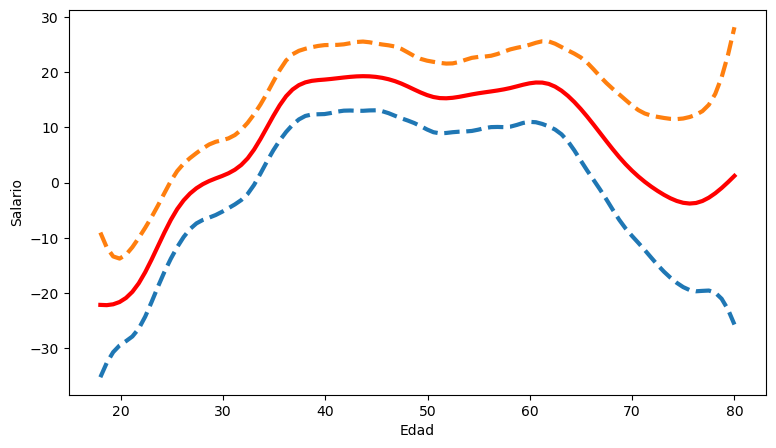

In [2]:
Wage = load_data("Wage")
education_code = Wage["education"].cat.codes
X = np.column_stack([Wage["age"],Wage["year"],education_code])
y = Wage["wage"].to_numpy()
#Creación del modelo
gam = LinearGAM(s(0)+ s(1)+f(2))
gam.fit(X,y)

#Predicciones
XX = gam.generate_X_grid(term = 0)
partial_age = gam.partial_dependence(term = 0, X=XX)

#Intervalos de confianza
pdep_age, confi_age = gam.partial_dependence(term = 0, X = XX, width = 0.95)

#Grafica de contribuciones

plt.figure(figsize = (9,5))
plt.plot(XX[:,0],pdep_age,linewidth = 3, color = "red")

plt.plot(XX[:,0],confi_age[:,0],linewidth = 3, linestyle = "--")

plt.plot(XX[:,0],confi_age[:,1],linewidth = 3, linestyle = "--")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.show()

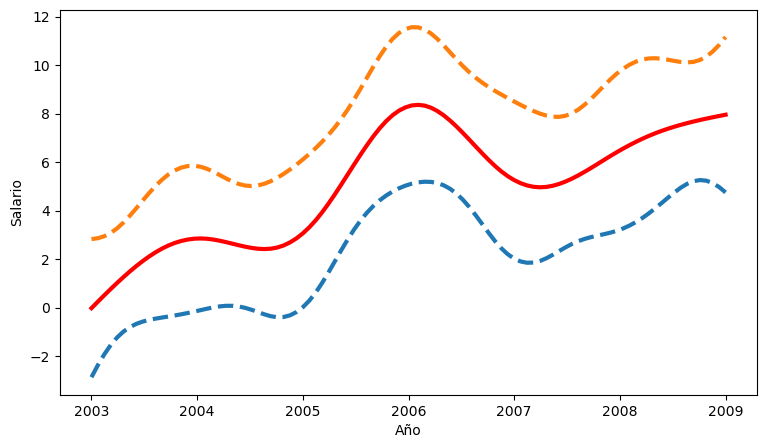

In [3]:
#Predicciones
XX = gam.generate_X_grid(term = 1)
partial_age = gam.partial_dependence(term = 1, X=XX)

#Intervalos de confianza
pdep_age, confi_age = gam.partial_dependence(term = 1, X = XX, width = 0.95)

#Grafica de contribuciones

plt.figure(figsize = (9,5))
plt.plot(XX[:,1],pdep_age,linewidth = 3, color = "red")

plt.plot(XX[:,1],confi_age[:,0],linewidth = 3, linestyle = "--")

plt.plot(XX[:,1],confi_age[:,1],linewidth = 3, linestyle = "--")

plt.xlabel("Año")
plt.ylabel("Salario")
plt.show()

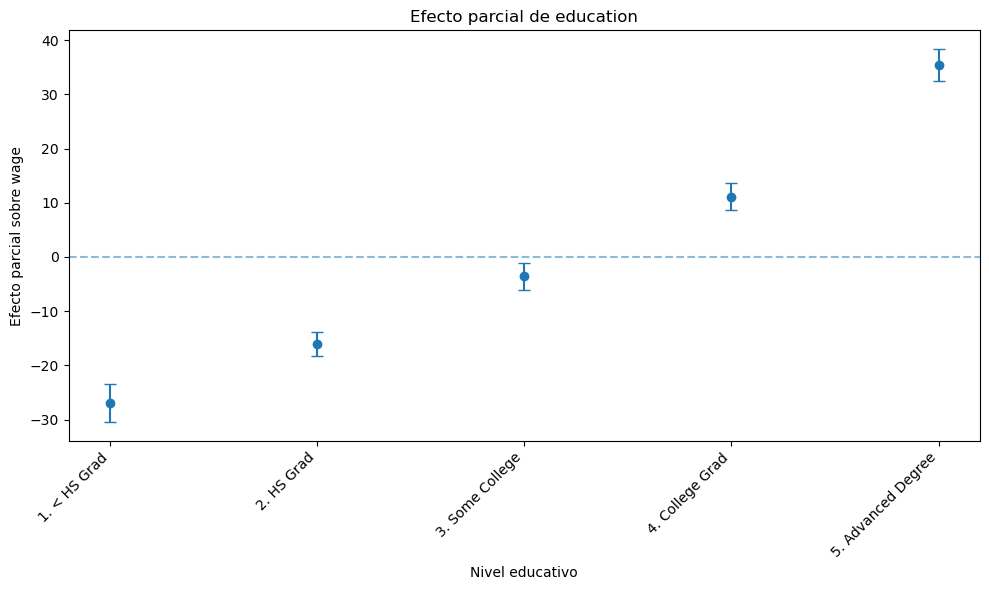

In [4]:
education_levels = Wage["education"].cat.categories
education_codes = np.arange(len(education_levels))
X_education = np.column_stack([
    np.repeat(Wage["age"].mean(), len(education_levels)),
    np.repeat(Wage["year"].mean(), len(education_levels)),
    education_codes
])

pdep_education, confi_education = gam.partial_dependence(term = 2, X = X_education, width = 0.95)

#figura
plt.figure(figsize=(10, 6))

x_pos = np.arange(len(education_levels))

plt.errorbar(
    x_pos,
    pdep_education,
    yerr=[
        pdep_education - confi_education[:, 0],
        confi_education[:, 1] - pdep_education
    ],
    fmt="o",
    capsize=4
)

plt.axhline(
    y=0,
    linestyle="--",
    alpha=0.5
)

plt.xticks(
    x_pos,
    education_levels,
    rotation=45,
    ha="right"
)

plt.xlabel("Nivel educativo")
plt.ylabel("Efecto parcial sobre wage")
plt.title("Efecto parcial de education")

plt.tight_layout()
plt.show()

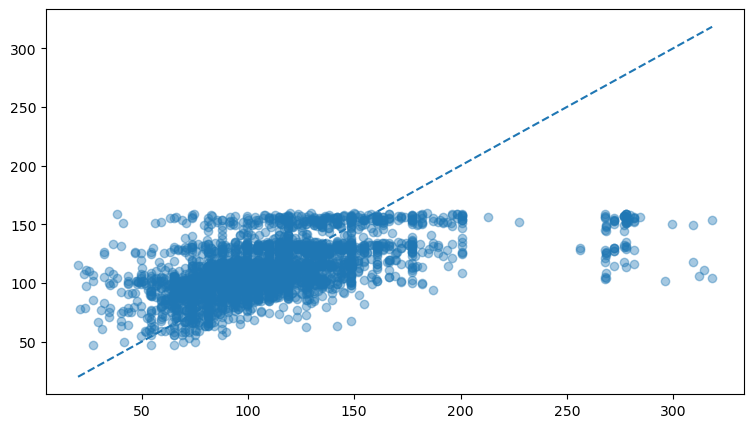

29901.488679868304


In [5]:
y_hat = gam.predict(X)
plt.figure(figsize=(9,5))
plt.scatter(y, y_hat, alpha = 0.4)
min_val = min(y.min(),y_hat.min())
max_val = max(y.max(),y_hat.max())

plt.plot([min_val,max_val],[min_val,max_val],linestyle = "--")

plt.show()
print(gam.statistics_["AIC"])

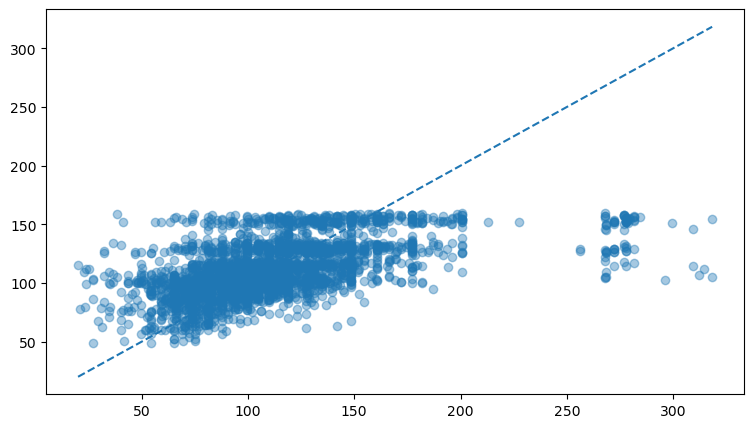

29896.52708223327


In [6]:
gam_year_linear = LinearGAM(s(0)+ l(1) + f(2)  )
gam_year_linear.fit(X,y)

y_hat = gam_year_linear.predict(X)
plt.figure(figsize=(9,5))
plt.scatter(y, y_hat, alpha = 0.4)
min_val = min(y.min(),y_hat.min())
max_val = max(y.max(),y_hat.max())

plt.plot([min_val,max_val],[min_val,max_val],linestyle = "--")

plt.show()

print(gam_year_linear.statistics_["AIC"])

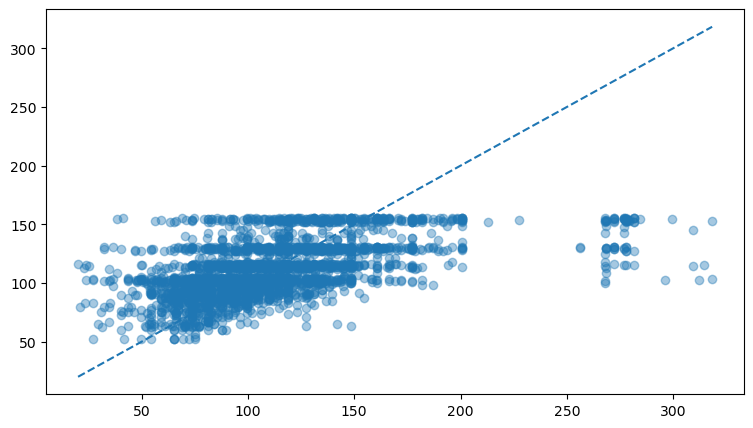

29909.314048515338


In [7]:
gam_year_linear = LinearGAM(s(0) + f(2)  )
gam_year_linear.fit(X,y)

y_hat = gam_year_linear.predict(X)
plt.figure(figsize=(9,5))
plt.scatter(y, y_hat, alpha = 0.4)
min_val = min(y.min(),y_hat.min())
max_val = max(y.max(),y_hat.max())

plt.plot([min_val,max_val],[min_val,max_val],linestyle = "--")

plt.show()
print(gam_year_linear.statistics_["AIC"])

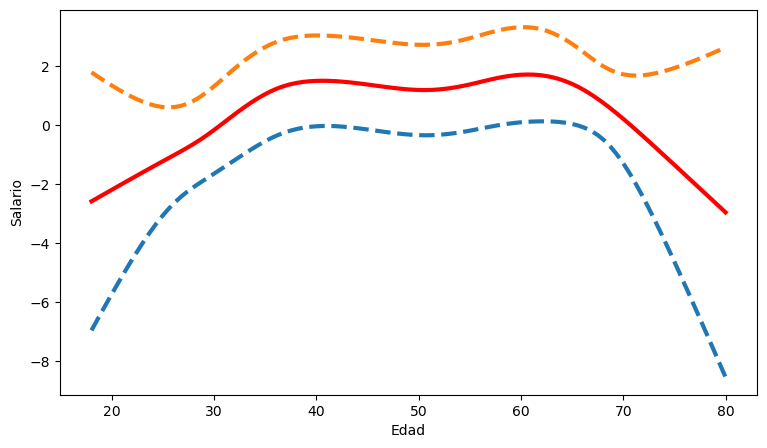

In [8]:
high_earn = (Wage["wage"]>250).astype(int)
gam_logit = LogisticGAM(s(0) + s(1) + f(2))
gam_logit.fit(X,high_earn)

pd.crosstab(Wage["education"], high_earn)

mask = (Wage["education"] != Wage["education"].cat.categories[0])
Wage_sub = Wage.loc[mask].copy()

education_sub = (
    Wage_sub["education"]
    .cat.remove_unused_categories()
    .cat.codes
)

X_sub = np.column_stack([
    Wage_sub["age"],
    Wage_sub["year"],
    education_sub
])

high_earn_sub = (
    Wage_sub["wage"] > 250
).astype(int)

gam = LogisticGAM(s(0) + s(1) + f(2))
gam.fit(X_sub,
                  high_earn_sub)

#Predicciones
XX = gam.generate_X_grid(term = 0)
partial_age = gam.partial_dependence(term = 0, X=XX)

#Intervalos de confianza
pdep_age, confi_age = gam.partial_dependence(term = 0, X = XX, width = 0.95)

#Grafica de contribuciones

plt.figure(figsize = (9,5))
plt.plot(XX[:,0],pdep_age,linewidth = 3, color = "red")

plt.plot(XX[:,0],confi_age[:,0],linewidth = 3, linestyle = "--")

plt.plot(XX[:,0],confi_age[:,1],linewidth = 3, linestyle = "--")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.show()


# Ejercicios

## Ejercicio 1. Interpretación de efectos parciales
Ajusta el modelo


Construye las tres gráficas de efectos parciales.

en base a age, year y education

Describe la forma de cada efecto.

Responde:

¿Qué edades parecen asociarse con mayores salarios?

RESPUESTA: Parecen asociarse con las edades que estan en el intervalo de 35 a 65 años

¿El efecto de year parece lineal?

RESPUESTA: No, pero si parece que es una grafica creciente.

¿Qué niveles educativos producen las mayores contribuciones?

RESPUESTA: Los mas altos.

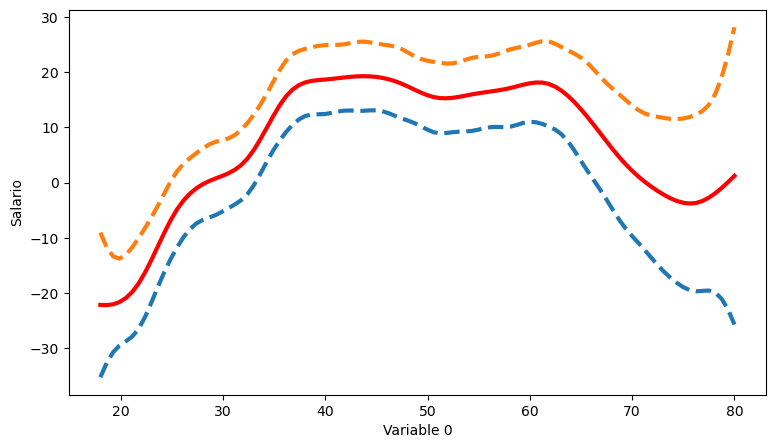

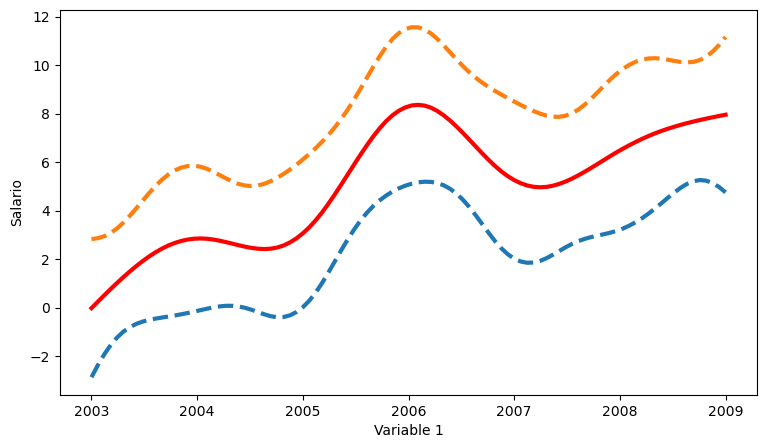

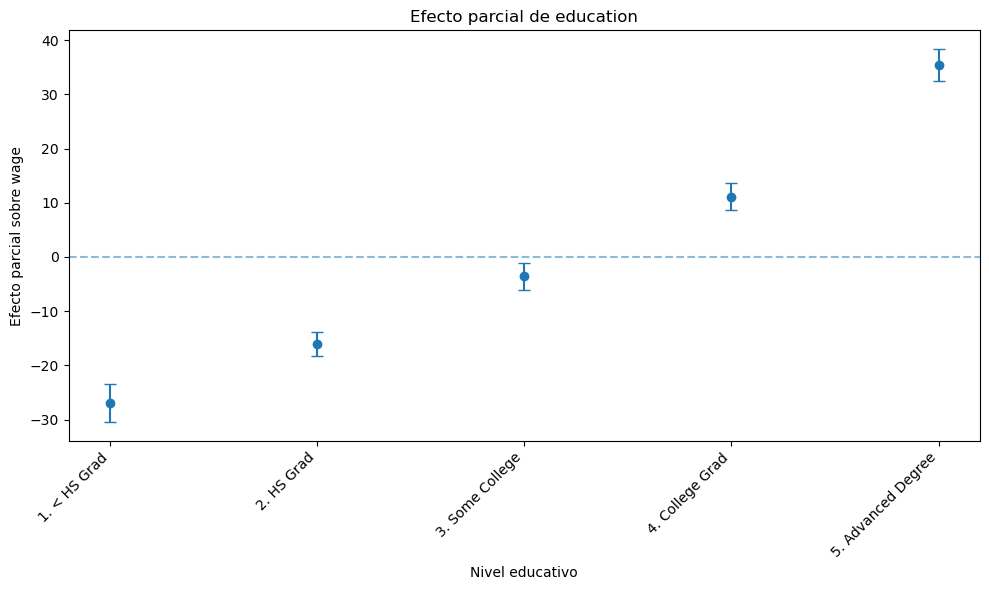

In [9]:
Wage = load_data("Wage")
education_code = Wage["education"].cat.codes
X = np.column_stack([Wage["age"],Wage["year"],education_code])
y = Wage["wage"].to_numpy()
#Creación del modelo
gam = LinearGAM(s(0)+ s(1)+f(2))
gam.fit(X,y)

Wage = load_data("Wage")
education_code = Wage["education"].cat.codes
X = np.column_stack([Wage["age"],Wage["year"],education_code])
y = Wage["wage"].to_numpy()
#Creación del modelo
gam = LinearGAM(s(0)+ s(1)+f(2))
gam.fit(X,y)

for i in range(0,2):
    #Predicciones
    XX = gam.generate_X_grid(term = i)
    partial_age = gam.partial_dependence(term = i, X=XX)
    
    #Intervalos de confianza
    pdep_age, confi_age = gam.partial_dependence(term = i, X = XX, width = 0.95)
    
    #Grafica de contribuciones
    
    plt.figure(figsize = (9,5))
    plt.plot(XX[:,i],pdep_age,linewidth = 3, color = "red")
    
    plt.plot(XX[:,i],confi_age[:,0],linewidth = 3, linestyle = "--")
    
    plt.plot(XX[:,i],confi_age[:,1],linewidth = 3, linestyle = "--")
    
    plt.xlabel(f"Variable {i}")
    plt.ylabel("Salario")
    plt.show()


education_levels = Wage["education"].cat.categories
education_codes = np.arange(len(education_levels))
X_education = np.column_stack([
    np.repeat(Wage["age"].mean(), len(education_levels)),
    np.repeat(Wage["year"].mean(), len(education_levels)),
    education_codes
])

pdep_education, confi_education = gam.partial_dependence(term = 2, X = X_education, width = 0.95)

#figura
plt.figure(figsize=(10, 6))

x_pos = np.arange(len(education_levels))

plt.errorbar(
    x_pos,
    pdep_education,
    yerr=[
        pdep_education - confi_education[:, 0],
        confi_education[:, 1] - pdep_education
    ],
    fmt="o",
    capsize=4
)

plt.axhline(
    y=0,
    linestyle="--",
    alpha=0.5
)

plt.xticks(
    x_pos,
    education_levels,
    rotation=45,
    ha="right"
)

plt.xlabel("Nivel educativo")
plt.ylabel("Efecto parcial sobre wage")
plt.title("Efecto parcial de education")

plt.tight_layout()
plt.show()

## Ejercicio 2
Ajusta dos modelos:

wage con age lineal

y

wage con age suave

Compara los modelos utilizando AIC.

¿Cuál prefieres?
RESPUESTA: En el que age es suave

In [10]:
Wage = load_data("Wage")
education_code = Wage["education"].cat.codes
X = np.column_stack([Wage["age"],Wage["year"],education_code])
y = Wage["wage"].to_numpy()
#Creación del modelo
gam1 = LinearGAM(s(0)+ s(1)+f(2))
gam1.fit(X,y)

gam2 = LinearGAM(l(0)+ s(1)+f(2))
gam2.fit(X,y)

print("AIC del modelo con age suave:",gam1.statistics_['AIC'])
print("AIC del modelo con age lineal:",gam2.statistics_['AIC'])



AIC del modelo con age suave: 29901.488679868304
AIC del modelo con age lineal: 30008.942863613625


## 7.24.3 Ejercicio 3. year lineal vs. no lineal
Repite el ejercicio anterior para year.

Compara:


¿Hay evidencia práctica de que necesitemos un efecto no lineal?

RESPUESTA: Si pero no mucha, basicamente esta a favor del efecto lineal solo por 5 puntos

In [11]:
Wage = load_data("Wage")
education_code = Wage["education"].cat.codes
X = np.column_stack([Wage["age"],Wage["year"],education_code])
y = Wage["wage"].to_numpy()
#Creación del modelo
gam1 = LinearGAM(s(0)+ s(1)+f(2))
gam1.fit(X,y)

gam2 = LinearGAM(s(0)+ l(1)+f(2))
gam2.fit(X,y)

print("AIC del modelo con year suave:",gam1.statistics_['AIC'])
print("AIC del modelo con year lineal:",gam2.statistics_['AIC'])


AIC del modelo con year suave: 29901.488679868304
AIC del modelo con year lineal: 29896.52708223327


## Ejercicio 4
Ajusta una regresión lineal múltiple utilizando:

age;
year;
education.
Después ajusta el GAM correspondiente.

Compara:

valores predichos;

error cuadrático medio;

AIC;

interpretabilidad.

RESPUESTA: Ambas predicciones parecen ser iguales ademas de que el error cuadratico medio como el AIC son bastante parecidos


In [12]:
#Regresion lineal
from statsmodels.tools.eval_measures import mse, rmse
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

regr = OLS(y, add_constant(X)).fit()
y_pred = regr.predict(add_constant(X))
print("AIC de regresión lineal: ",regr.aic)
print("MSE de regresión lineal: ",mse(y,y_pred))

AIC de regresión lineal:  30022.581567221547
MSE de regresión lineal:  1295.9294724140648


In [13]:
#GAM
Wage = load_data("Wage")
education_code = Wage["education"].cat.codes
X = np.column_stack([Wage["age"],Wage["year"],education_code])
y = Wage["wage"].to_numpy()
#Creación del modelo
gam1 = LinearGAM(l(0)+ l(1)+f(2))
gam1.fit(X,y)
pred =gam1.predict(X)
print("AIC del gam:",gam1.statistics_['AIC'])
print("MSE del gam:", mse(y,pred))

AIC del gam: 30004.61785739624
MSE del gam: 1284.7628658944307


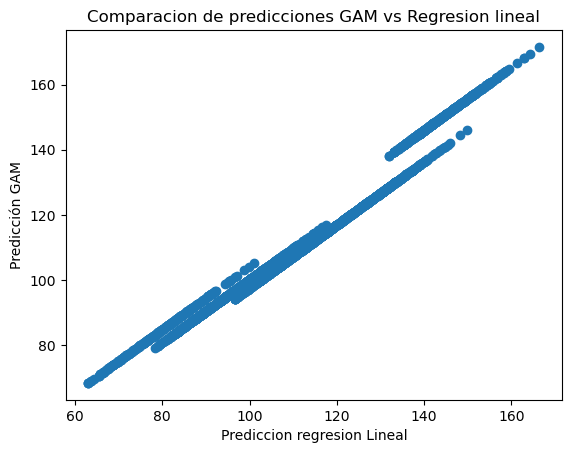

In [14]:
plt.figure()
plt.scatter(y_pred,pred)
plt.title("Comparacion de predicciones GAM vs Regresion lineal")
plt.xlabel("Prediccion regresion Lineal")
plt.ylabel("Predicción GAM")
plt.show()

## 7.24.5 Ejercicio 5. Clasificación
Construye la variable


Ajusta un GAM logístico utilizando:

age;

year;

education.

Construye las gráficas de efectos parciales.

¿Cambian las conclusiones respecto al modelo que utiliza el umbral 250?

No, Las gráficas parecen ser bastante parecidas

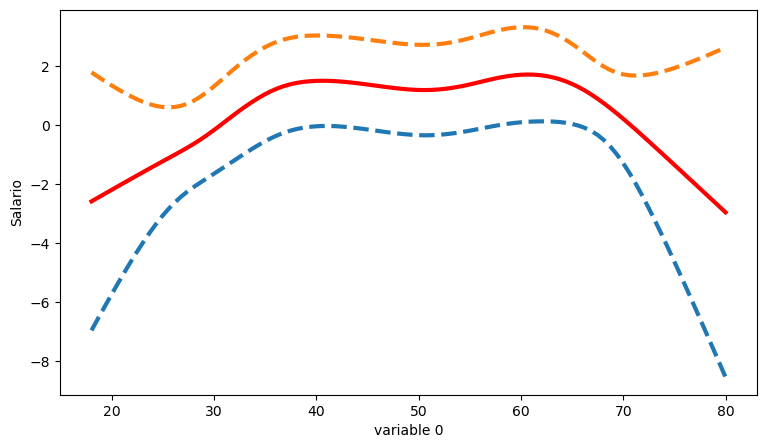

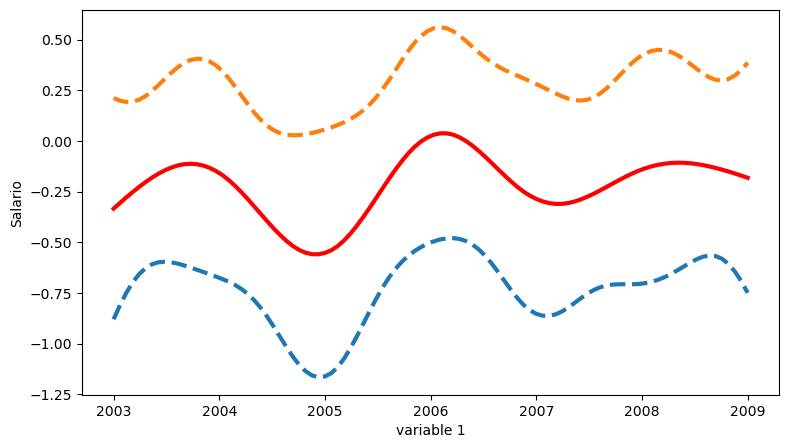

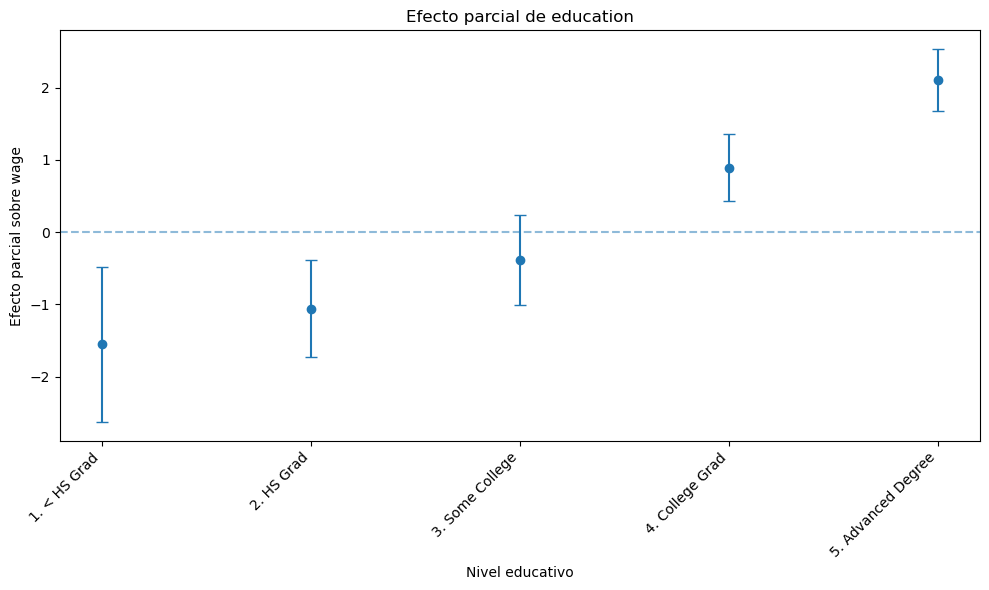

In [15]:
high_earn = (Wage["wage"]>200).astype(int)
gam_logit = LogisticGAM(s(0) + s(1) + f(2))
gam_logit.fit(X,high_earn)

pd.crosstab(Wage["education"], high_earn)

mask = (Wage["education"] != Wage["education"].cat.categories[0])
Wage_sub = Wage.loc[mask].copy()

education_sub = (
    Wage_sub["education"]
    .cat.remove_unused_categories()
    .cat.codes
)

X_sub = np.column_stack([
    Wage_sub["age"],
    Wage_sub["year"],
    education_sub
])

high_earn_sub = (
    Wage_sub["wage"] > 250
).astype(int)

gam = LogisticGAM(s(0) + s(1) + f(2))
gam.fit(X_sub,
                  high_earn_sub)

for i in range(0,2):

    #Predicciones
    XX = gam.generate_X_grid(term = i)
    partial_age = gam.partial_dependence(term = i, X=XX)
    
    #Intervalos de confianza
    pdep_age, confi_age = gam.partial_dependence(term = i, X = XX, width = 0.95)
    
    #Grafica de contribuciones
    
    plt.figure(figsize = (9,5))
    plt.plot(XX[:,i],pdep_age,linewidth = 3, color = "red")
    
    plt.plot(XX[:,i],confi_age[:,0],linewidth = 3, linestyle = "--")
    
    plt.plot(XX[:,i],confi_age[:,1],linewidth = 3, linestyle = "--")
    
    plt.xlabel(f"variable {i}")
    plt.ylabel("Salario")
    plt.show()


education_levels = Wage["education"].cat.categories
education_codes = np.arange(len(education_levels))
X_education = np.column_stack([
    np.repeat(Wage["age"].mean(), len(education_levels)),
    np.repeat(Wage["year"].mean(), len(education_levels)),
    education_codes
])

pdep_education, confi_education = gam_logit.partial_dependence(term = 2, X = X_education, width = 0.95)

#figura
plt.figure(figsize=(10, 6))

x_pos = np.arange(len(education_levels))

plt.errorbar(
    x_pos,
    pdep_education,
    yerr=[
        pdep_education - confi_education[:, 0],
        confi_education[:, 1] - pdep_education
    ],
    fmt="o",
    capsize=4
)

plt.axhline(
    y=0,
    linestyle="--",
    alpha=0.5
)

plt.xticks(
    x_pos,
    education_levels,
    rotation=45,
    ha="right"
)

plt.xlabel("Nivel educativo")
plt.ylabel("Efecto parcial sobre wage")
plt.title("Efecto parcial de education")

plt.tight_layout()
plt.show()

## 7.24.6 Ejercicio 6. Interpretación
Explica con tus propias palabras la diferencia entre

Modelo Gam Lineal

y

Modelo GAM no Lineal

Tu explicación debe mencionar:

linealidad;

flexibilidad;

aditividad;

interpretación de 
f1 y f2.

RESPUESTA: La diferencia entre uno y otro es asumir que la variable Y sigue o no una dinamica lineal en base a las otras variables lo cual no puede ser tan cierto en algunos casos ya que la regresión lineal es menos flexible que la no lineal, pero gana que es mas interpretable que a un ragresión gam gen